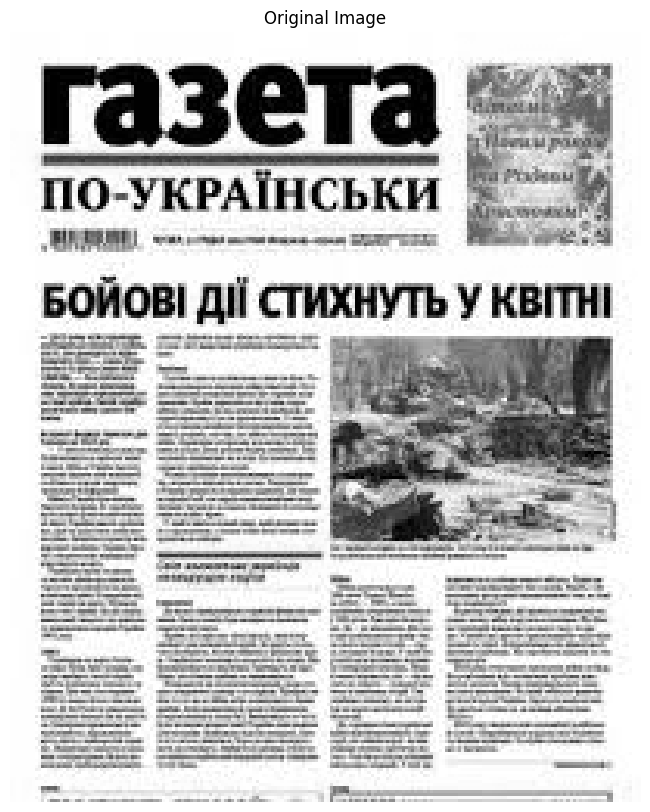

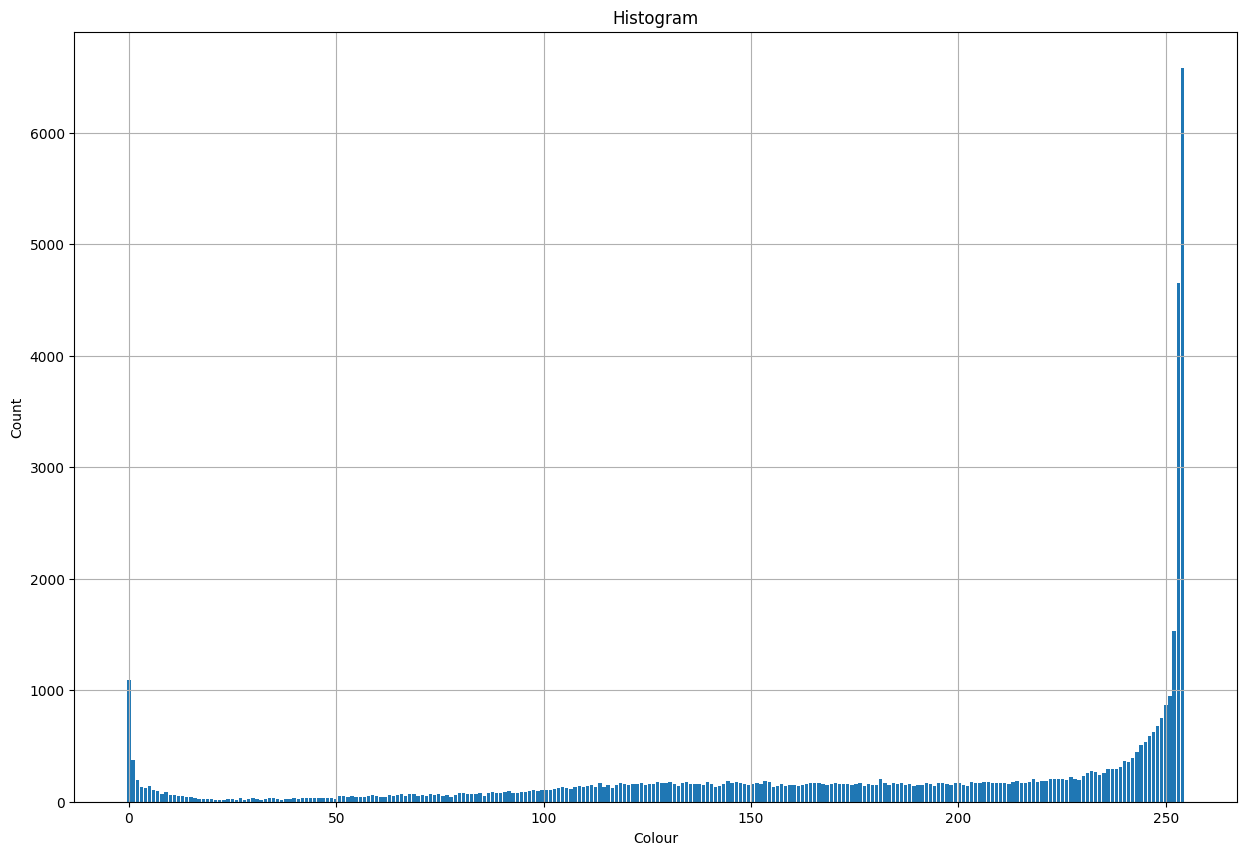

Optimal threshold: 164


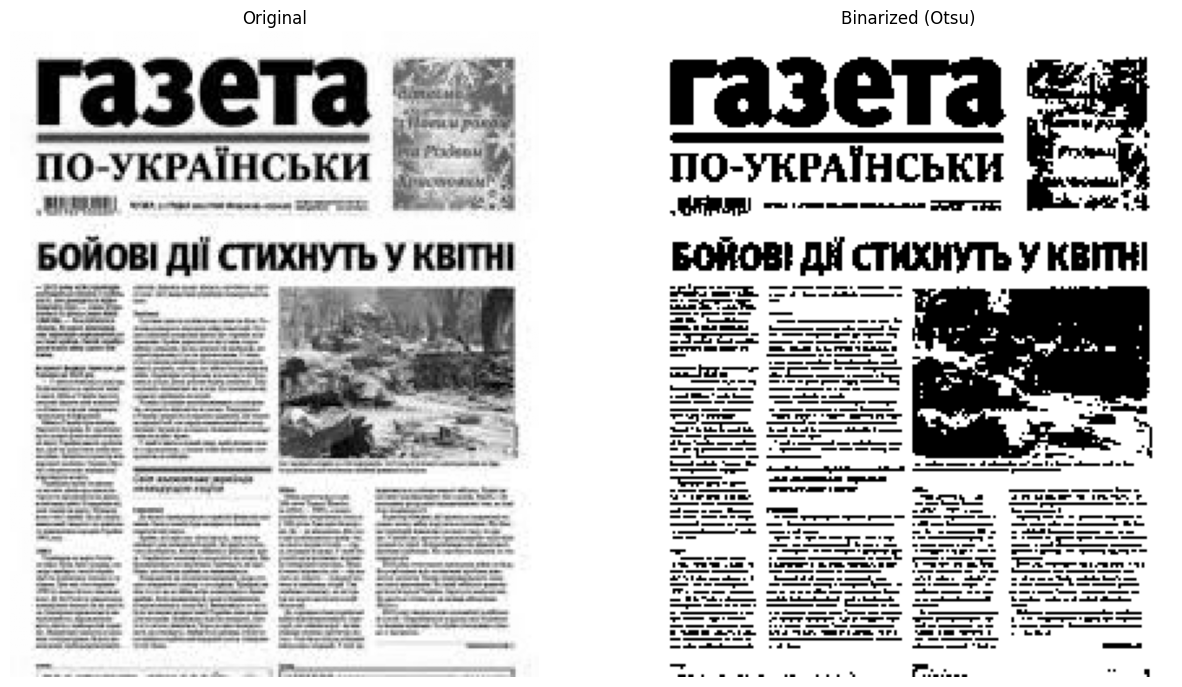

In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('document (2).jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


h = np.histogram(img, 256)

plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour')
plt.ylabel('Count')
plt.title("Histogram")
plt.grid(True)
plt.show()
rows, cols = img.shape


num_pixels = rows * cols


best_wcv = 1e12
opt_th = 0

for th in range(0, 256):


    foreground = img[img <= th]


    background = img[img > th]

    if len(foreground) == 0 or len(background) == 0:
        continue


    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels


    sigma_f = np.var(foreground)
    sigma_b = np.var(background)


    wcv = omega_f * sigma_f + omega_b * sigma_b


    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th


print("Optimal threshold:", opt_th)

plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(122)
plt.imshow(img > opt_th, cmap='gray')
plt.title("Binarized (Otsu)")
plt.axis('off')

plt.show()

## Висновки та відповіді на контрольні питання

**1. Чи можна вважати гістограму бімодальною?**
Гістограму можна вважати приблизно бімодальною:
- Один пік відповідає темним пікселям (текст), інший — світлим пікселям (фон).
- Проте піки не завжди чітко відокремлені через шум, тіні та нерівномірне освітлення.

**2. Який поріг бінаризації обрали б і чому?**
Поріг слід обирати в «провалі» між двома піками гістограми, тобто там, де мінімізується змішування класів.
- Це дозволяє максимально чітко розділити текст і фон.
- Алгоритм Оцу знаходить оптимальний поріг автоматично, який зазвичай збігається з цією точкою.

**3. Чи достатньо хорошою є бінаризація тексту для подальшого розпізнавання?**
- Текст на зображенні добре виділений, фон майже чистий.
- Для простих документів цього зазвичай достатньо для OCR (розпізнавання тексту).
- Проте для складних умов (нерівномірне освітлення, шум, тіні) може знадобитися адаптивна бінаризація або додаткове попереднє оброблення.

## Аналіз результату застосування Otsu Threshold

**1. Наскільки отриманий результат відрізняється від оригінального зображення?**
- Отримане бінаризоване зображення сильно відрізняється від оригіналу:
  - фон став білим (пікселі 1 або True),
  - текст став чорним (пікселі 0 або False).
- Втрачаються деталі градієнтів і кольорів, оскільки всі відтінки сірого зводяться до двох рівнів.

**2. Чи буде корисним отриманий результат для подальшого застосування документа для розпізнавання символів (OCR)?**
- Так, для **чорно-білих документів з чітким текстом** бінаризація значно полегшує розпізнавання:
  - текст чітко виділений на фоні,
  - алгоритми OCR швидше і точніше визначають символи.
- Для **сканованих або фотозображень з тінями, шумом або кольоровим фоном** результат може бути **менш точним**:
  - деякі символи можуть зникнути або з’єднатися з фоном,
  - може знадобитися додаткове попереднє оброблення (шумозаглушення, адаптивна бінаризація).

**Висновок:**
- Otsu threshold добре працює для чистих документів.
- Для складних документів варто застосовувати додаткову обробку або адаптивну бінаризацію, щоб підготувати зображення для OCR.

## Аналіз графіка cost і оптимізації

**1. Що відображено на графіку cost і що допомагає зрозуміти?**
- На графіку показано **поверхню втрат (cost surface)** залежно від двох параметрів прямої:
  - нахил (slope / α)
  - офсет (offset / c)
- Темні регіони означають **менші значення функції втрат**, тобто параметри, при яких пряма краще підходить до даних.
- Світлі області відповідають **великим втратам**, де пряма погано описує дані.

**2. Який нахил лінії відповідає мінімальному значенню функції втрат?**
- Мінімальне значення втрат відповідає тому нахилу прямої (α), який розташований у темній зоні на графіку (найнижча точка поверхні).
- Цей нахил можна знайти програмно, знаходячи індекс мінімуму масиву `cost`.

**3. Який офсет прямої відповідає мінімальному значенню функції втрат?**
- Аналогічно, офсет відповідає індексу по осі offset, де функція втрат мінімальна.
- Це точка (slope, offset), що лежить у найтемнішому регіоні графіка.

**4. Чи відповідають ці значення параметрам прямої, яка була використана для формування набору даних?**
- Так, знайдені параметри (нахил і офсет) **наближено збігаються з реальними параметрами**, які ми задавали при генерації даних:
  - slope ≈ tan(45°)
  - offset ≈ 1
- Через шум та викиди значення можуть трохи відрізнятися.

**5. Як отримати значення точки з мінімальними втратами і вивести параметри?**
```python
idx_min = np.unravel_index(np.argmin(cost), cost.shape)
best_offset = offset[idx_min[0]]
best_alpha = alpha[idx_min[1]]
best_slope = np.tan(np.deg2rad(best_alpha))
min_cost = cost[idx_min]

print("Найкращий нахил (slope):", best_slope)
print("Найкращий офсет (offset):", best_offset)
print("Мінімальна функція втрат:", min_cost)
```
**6. Рушій, який допомагає знайти напрямок до мінімуму функції втрат**

- Рушієм є **градієнт функції втрат**, який показує напрямок найшвидшого зменшення втрат.
- Алгоритм, що використовує градієнт для руху до мінімуму, називається **градієнтний спуск (Gradient Descent)**.
- Цей метод застосовується не тільки для прямої, а й для будь-яких моделей машинного навчання.
